# 02 — Preprocesamiento y Data Augmentation
## Clasificación de Enfermedades en Hojas de Plantas mediante CNN
**Dataset:** PlantVillage  


---

## Objetivo
Este notebook implementa el pipeline completo de preparación de datos:
1. Redimensionamiento y normalización de imágenes
2. División estratificada en conjuntos train / validation / test
3. Control de calidad (imágenes corruptas, duplicadas)
4. Data Augmentation con justificación técnica de cada técnica
5. Análisis comparativo del impacto del augmentation


In [ ]:
# -----------------------------------------------------------------
# IMPORTACIONES
# -----------------------------------------------------------------
import os
import random
import shutil
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
from tqdm import tqdm
import hashlib

import torch
import torchvision
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# Reproducibilidad total
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



---
## 1. Configuración del pipeline

Parámetros centralizados. Aquí se define el tamaño de imagen objetivo, proporciones de división y rutas de salida.


In [ ]:
# ------------------------------------------------------------------
# PARÁMETROS GLOBALES
# ------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# -- Rutas ---------------------------------------------------------
DATASET_PATH = Path("/content/drive/MyDrive/Universidad/9no ciclo/CIENCIA DE DATOS/PC3/PlantVillage")
OUTPUT_PATH  = Path("/content/drive/MyDrive/Universidad/9no ciclo/CIENCIA DE DATOS/PC3/dataset_procesado")
OUTPUT_PATH.mkdir(exist_ok=True)

# Verificar dataset
if not DATASET_PATH.exists():
    print(" ADVERTENCIA: La ruta del dataset no existe.")
    print(f"   Ruta esperada: {DATASET_PATH.resolve()}")
else:
    clases = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
    print(f" Dataset encontrado: {len(clases)} clases")

# -- Dimensiones ------------------------------------------------------
IMG_SIZE = 224
# Justificación: Los modelos preentrenados en ImageNet usan 224×224.
# Usar este tamaño permite transfer learning sin interpolaciones costosas.

# -- División del dataset -----------------------------------------------
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
# Justificación: División 70/15/15 balanceada para detectar overfitting
# en validación y tener un conjunto de test limpio para reporte final.

# -- Normalización (estadísticas ImageNet) ---------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
# Justificación: Al usar modelos preentrenados en ImageNet, se aplican
# las mismas estadísticas de normalización para mantener la distribución
# de entrada que el modelo espera.

# -- Batch size -----------------------------------------------------
BATCH_SIZE = 32

print(" Configuración:")
print(f"   Dataset original : {DATASET_PATH}")
print(f"   Salida procesada : {OUTPUT_PATH}")
print(f"   Tamaño de imagen : {IMG_SIZE}×{IMG_SIZE} px")
print(f"   División         : Train={TRAIN_RATIO} | Val={VAL_RATIO} | Test={TEST_RATIO}")
print(f"   Normalización    : ImageNet mean/std")
print(f"   Batch size       : {BATCH_SIZE}")


Mounted at /content/drive
 Dataset encontrado: 15 clases
 Configuración:
   Dataset original : /content/drive/MyDrive/Universidad/9no ciclo/CIENCIA DE DATOS/PC3/PlantVillage
   Salida procesada : /content/drive/MyDrive/Universidad/9no ciclo/CIENCIA DE DATOS/PC3/dataset_procesado
   Tamaño de imagen : 224×224 px
   División         : Train=0.7 | Val=0.15 | Test=0.15
   Normalización    : ImageNet mean/std
   Batch size       : 32


---
## 2. Control de calidad: imágenes corruptas y duplicadas

Antes de dividir el dataset, se eliminan imágenes problemáticas para evitar errores durante el entrenamiento.


In [ ]:
# ------------------------------------------------------------------
# DETECCIÓN Y REMOCIÓN DE IMÁGENES CORRUPTAS
# ----------------------------------------------------------------
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}

corrupted_files  = []
all_image_paths  = []

print(" Escaneando imágenes...")
for class_dir in tqdm(sorted(DATASET_PATH.iterdir()), desc="Clases"):
    if not class_dir.is_dir():
        continue
    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() not in VALID_EXT:
            continue
        try:
            with Image.open(img_path) as img:
                img.verify()
            all_image_paths.append(img_path)
        except Exception as e:
            corrupted_files.append((img_path, str(e)))

print(f" Escaneo completo:")
print(f"   Imágenes válidas   : {len(all_image_paths):,}")
print(f"   Imágenes corruptas : {len(corrupted_files)}")
if corrupted_files:
    print("\n   Archivos corruptos detectados (se excluirán):")
    for p, e in corrupted_files[:10]:
        print(f"     {p.name}: {e}")


 Escaneando imágenes...


Clases: 100%|██████████| 15/15 [10:27<00:00, 41.84s/it]

 Escaneo completo:
   Imágenes válidas   : 21,563
   Imágenes corruptas : 0


In [ ]:
# -----------------------------------------------------------------
# DETECCIÓN DE DUPLICADOS (por hash MD5)
# Nota: en PlantVillage algunos duplicados son intencionales (mismo
# segmento de imagen en distintas clases). Se reportan pero no se
# eliminan automáticamente.
# ------------------------------------------------------------------
print(" Detectando duplicados...")
hash_map = {}
duplicados = []

# Muestra del 20% para no extender demasiado el tiempo
muestra_dup = random.sample(all_image_paths, int(len(all_image_paths) * 0.20))

for img_path in tqdm(muestra_dup, desc="Hashing"):
    try:
        with open(img_path, 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hash_map:
            duplicados.append((img_path, hash_map[h]))
        else:
            hash_map[h] = img_path
    except:
        pass

dup_rate = len(duplicados) / len(muestra_dup) * 100
print(f"\n   Muestra analizada  : {len(muestra_dup):,} imágenes (20%)")
print(f"   Duplicados hallados: {len(duplicados)} ({dup_rate:.2f}%)")
if dup_rate < 1.0:
    print("    Tasa de duplicados < 1% — No se requiere limpieza agresiva.")
else:
    print("     Tasa de duplicados alta — Revisar manualmente antes de entrenar.")


 Detectando duplicados...


Hashing: 100%|██████████| 4312/4312 [00:20<00:00, 215.22it/s]


   Muestra analizada  : 4,312 imágenes (20%)
   Duplicados hallados: 62 (1.44%)
     Tasa de duplicados alta — Revisar manualmente antes de entrenar.


---
## 3. División estratificada Train / Validation / Test

Se usa **split estratificado** para garantizar que cada clase tenga representación proporcional en los tres conjuntos. Esto es crítico para evitar data leakage y métricas sesgadas.

**¿Por qué estratificado?**  
Un split aleatorio simple podría, por azar, dejar clases minoritarias sin representación en validación o test. El split estratificado asegura que la distribución de clases se preserve en cada partición.


In [ ]:
# -------------------------------------------------------------------
# DIVISIÓN ESTRATIFICADA CON SKLEARN
# -------------------------------------------------------------------
print(" Dividiendo dataset de forma estratificada...")

# Construir lista de (path, label)
paths_labels = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    label = class_dir.name
    imgs = [f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXT]
    for img in imgs:
        if img not in [c for c, _ in corrupted_files]:
            paths_labels.append((str(img), label))

paths_arr  = np.array([p for p, _ in paths_labels])
labels_arr = np.array([l for _, l in paths_labels])

# Split 1: train vs (val + test)
paths_train, paths_valtest, y_train, y_valtest = train_test_split(
    paths_arr, labels_arr,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=labels_arr,
    random_state=SEED
)

# Split 2: val vs test (dentro del conjunto valtest)
val_rel = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
paths_val, paths_test, y_val, y_test = train_test_split(
    paths_valtest, y_valtest,
    test_size=(1 - val_rel),
    stratify=y_valtest,
    random_state=SEED
)

print(f"\n TAMAÑOS DE PARTICIONES:")
print(f"   Train      : {len(paths_train):>7,} imágenes ({len(paths_train)/len(paths_arr)*100:.1f}%)")
print(f"   Validation : {len(paths_val):>7,} imágenes ({len(paths_val)/len(paths_arr)*100:.1f}%)")
print(f"   Test       : {len(paths_test):>7,} imágenes ({len(paths_test)/len(paths_arr)*100:.1f}%)")
print(f"   TOTAL      : {len(paths_arr):>7,} imágenes (100%)")


 Dividiendo dataset de forma estratificada...

 TAMAÑOS DE PARTICIONES:
   Train      :  15,094 imágenes (70.0%)
   Validation :   3,234 imágenes (15.0%)
   Test       :   3,235 imágenes (15.0%)
   TOTAL      :  21,563 imágenes (100%)


In [ ]:
# ----------------------------------------------------------------
# VERIFICACIÓN DEL SPLIT — Distribución por clase en cada partición
# ---------------------------------------------------------------
df_train = pd.DataFrame({'path': paths_train, 'label': y_train, 'split': 'train'})
df_val   = pd.DataFrame({'path': paths_val,   'label': y_val,   'split': 'val'})
df_test  = pd.DataFrame({'path': paths_test,  'label': y_test,  'split': 'test'})
df_all   = pd.concat([df_train, df_val, df_test])

# Verificar proporciones
pivot = df_all.groupby(['label','split'])['path'].count().unstack(fill_value=0)
pivot['total']      = pivot.sum(axis=1)
pivot['%_train']    = (pivot['train'] / pivot['total'] * 100).round(1)
pivot['%_val']      = (pivot.get('val', 0) / pivot['total'] * 100).round(1)
pivot['%_test']     = (pivot.get('test', 0) / pivot['total'] * 100).round(1)

# Verificar que ninguna clase quedó vacía
train_empty = (pivot['train'] == 0).sum()
val_empty   = (pivot.get('val', pd.Series(0)) == 0).sum()
test_empty  = (pivot.get('test', pd.Series(0)) == 0).sum()

print(f"\n Verificación de integridad del split:")
print(f"   Clases con 0 imgs en train : {train_empty}")
print(f"   Clases con 0 imgs en val   : {val_empty}")
print(f"   Clases con 0 imgs en test  : {test_empty}")
print()
print("   Primeras 5 clases (proporciones):")
print(pivot[['train','val','test','%_train','%_val','%_test']].head(5).to_string())

# Exportar splits
df_all.to_csv('dataset_splits.csv', index=False, encoding='utf-8')
print("\n Splits guardados: dataset_splits.csv")



 Verificación de integridad del split:
   Clases con 0 imgs en train : 0
   Clases con 0 imgs en val   : 0
   Clases con 0 imgs en test  : 0

   Primeras 5 clases (proporciones):
split                          train  val  test  %_train  %_val  %_test
label                                                                  
Pepper__bell___Bacterial_spot    698  150   149     70.0   15.0    14.9
Pepper__bell___healthy          2069  443   444     70.0   15.0    15.0
Potato___Early_blight            700  150   150     70.0   15.0    15.0
Potato___Late_blight             700  150   150     70.0   15.0    15.0
Potato___healthy                 106   23    23     69.7   15.1    15.1

 Splits guardados: dataset_splits.csv


In [ ]:
# ------------------------------------------------------------------
# ORGANIZACIÓN EN CARPETAS train/val/test (estructura ImageFolder)
#   OPCIONAL: Ejecutar solo si se quiere guardar las imágenes
#    organizadas en disco. Requiere espacio adicional (~500MB).
# ----------------------------------------------------------

COPY_TO_DISK = True  # ← Cambiar a True para ejecutar

if COPY_TO_DISK:
    print(" Organizando imágenes en carpetas...")
    for split_name, df_split in [('train', df_train), ('val', df_val), ('test', df_test)]:
        for _, row in tqdm(df_split.iterrows(), desc=split_name, total=len(df_split)):
            dest_dir = OUTPUT_PATH / split_name / row['label']
            dest_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(row['path'], dest_dir / Path(row['path']).name)
    print(f"\n Imágenes organizadas en: {OUTPUT_PATH}")
    print(f"   Estructura: {OUTPUT_PATH}/[train|val|test]/[clase]/imagen.jpg")
else:
    print("ℹ  COPY_TO_DISK = False — Las imágenes NO se copian a disco.")
    print("   Los DataLoaders usarán el dataset original con índices del CSV.")


 Organizando imágenes en carpetas...


test: 100%|██████████| 3235/3235 [01:50<00:00, 29.15it/s]


 Imágenes organizadas en: /content/drive/MyDrive/Universidad/9no ciclo/CIENCIA DE DATOS/PC3/dataset_procesado
   Estructura: /content/drive/MyDrive/Universidad/9no ciclo/CIENCIA DE DATOS/PC3/dataset_procesado/[train|val|test]/[clase]/imagen.jpg


---
## 4. Definición de Transforms: Base y Augmentation

Se definen dos conjuntos de transformaciones:
- **`transform_base`**: Solo redimensionamiento + normalización. Sin augmentation. Para validación y test.
- **`transform_aug`**: Augmentation completo. Solo para train.

### Justificación de cada técnica:


In [ ]:
# -------------------------------------------------------------
# TRANSFORM BASE (val y test)
# -------------------------------------------------------------
transform_base = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),

    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

])

# --------------------------------------------------------------------
# TRANSFORM CON AUGMENTATION (solo train)
# ------------------------------------------------------------------
transform_aug = T.Compose([
    T.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),


    T.RandomCrop(IMG_SIZE),

    T.RandomHorizontalFlip(p=0.5),

    T.RandomVerticalFlip(p=0.3),

    T.RandomRotation(degrees=30),

    T.ColorJitter(
        brightness=0.3,   # ± variación de brillo
        contrast=0.3,     # ± variación de contraste
        saturation=0.3,   # ± variación de saturación
        hue=0.05          # ± variación de tono (conservadora)
    ),
    # ↑ Variación de color.
    #   JUSTIFICACIÓN: Las condiciones de iluminación varían en campo.
    #   Esto simula distintas horas del día o condiciones de luz.
    #   hue=0.05 es conservador — cambios grandes de tono pueden alterar la apariencia
    #   visual de síntomas de enfermedad (manchas marrones podrían verse distintas).

    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),

    T.RandomGrayscale(p=0.05),


    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(" Transforms definidos:")
print("\n transform_base (val/test):")
for t in transform_base.transforms:
    print(f"   → {t.__class__.__name__}")

print("\n transform_aug (train):")
for t in transform_aug.transforms:
    print(f"   → {t.__class__.__name__}")


 Transforms definidos:

 transform_base (val/test):
   → Resize
   → ToTensor
   → Normalize

 transform_aug (train):
   → Resize
   → RandomCrop
   → RandomHorizontalFlip
   → RandomVerticalFlip
   → RandomRotation
   → ColorJitter
   → RandomAffine
   → RandomGrayscale
   → ToTensor
   → Normalize


---
## 5. Visualización comparativa: Original vs Augmented

Se visualiza el efecto de cada técnica de augmentation sobre la misma imagen de referencia.


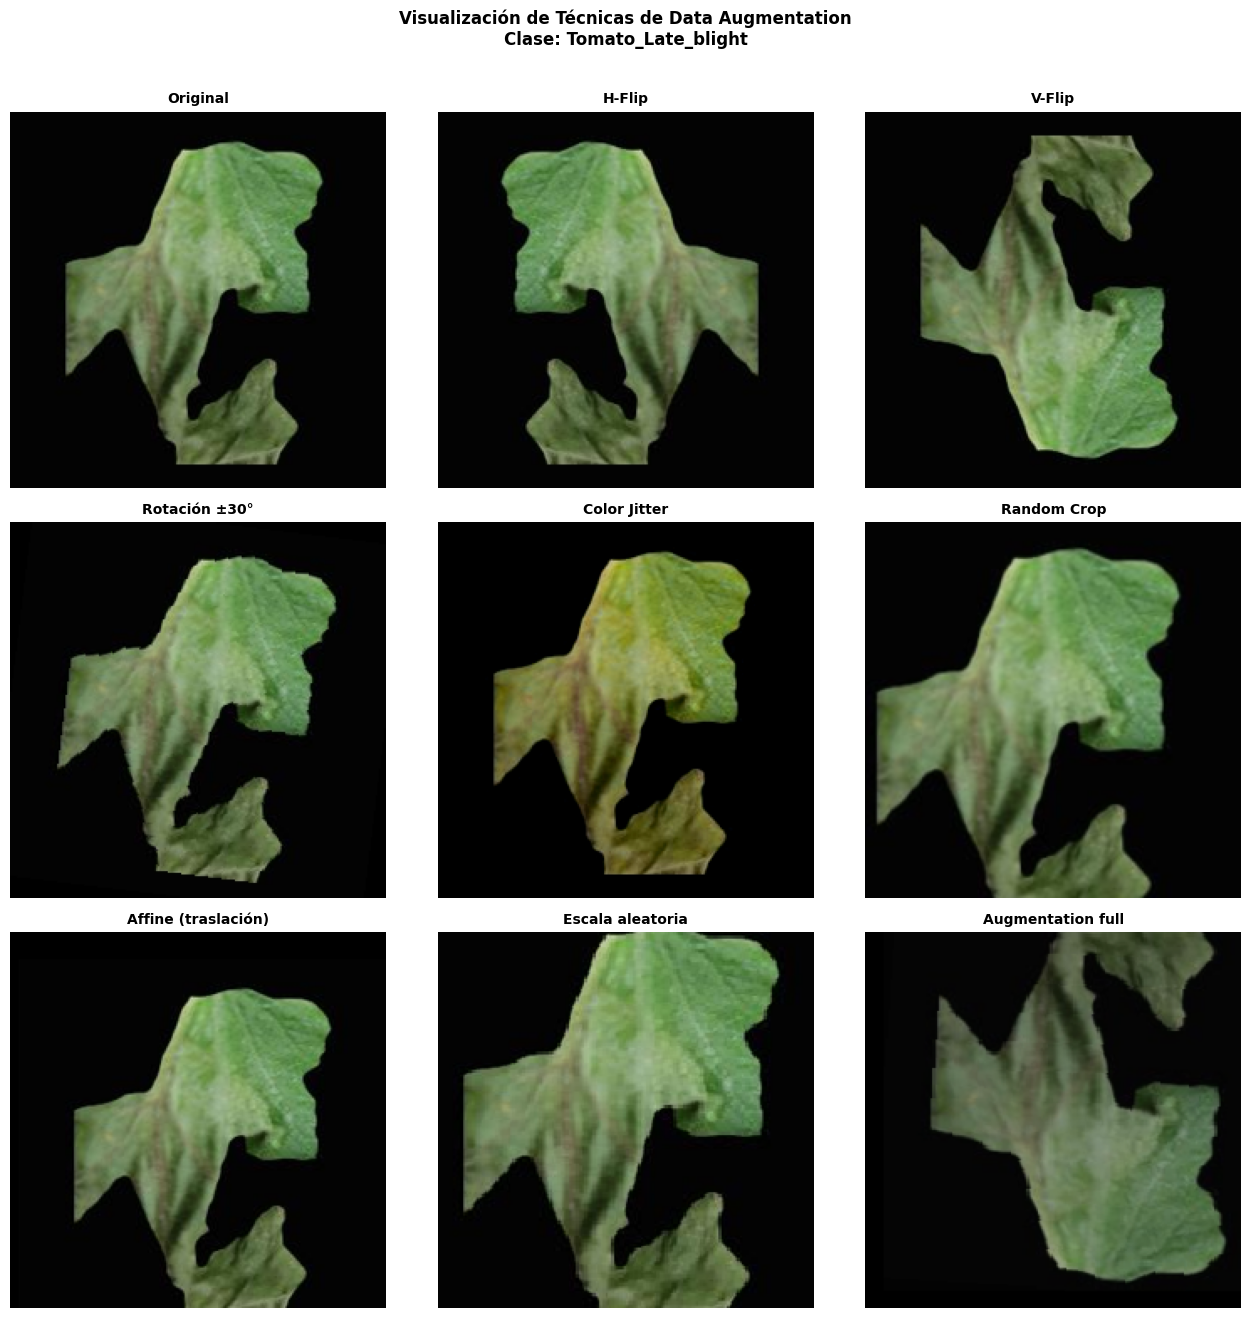

 Gráfico guardado: aug_visualizacion_tecnicas.png


In [ ]:
# ------------------------------------------------------------------
# VISUALIZACIÓN DE AUGMENTACIONES INDIVIDUALES
# ---------------------------------------------------------------
# Seleccionar una imagen de muestra
sample_path = random.choice(list(DATASET_PATH.rglob('*.jpg')))
img_orig = Image.open(sample_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

# Transformaciones individuales para visualizar cada efecto
augmentations_demo = {
    'Original'           : T.Compose([]),
    'H-Flip'             : T.RandomHorizontalFlip(p=1.0),
    'V-Flip'             : T.RandomVerticalFlip(p=1.0),
    'Rotación ±30°'      : T.RandomRotation(30),
    'Color Jitter'       : T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),
    'Random Crop'        : T.Compose([T.Resize(IMG_SIZE+40), T.RandomCrop(IMG_SIZE)]),
    'Affine (traslación)': T.RandomAffine(degrees=0, translate=(0.15, 0.15)),
    'Escala aleatoria'   : T.RandomAffine(degrees=0, scale=(0.7, 1.3)),
    'Augmentation full'  : T.Compose([t for t in transform_aug.transforms
                                       if not isinstance(t, (T.ToTensor, T.Normalize))]),
}

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.flatten()

for ax, (nombre, transf) in zip(axes, augmentations_demo.items()):
    try:
        img_aug = transf(img_orig) if len(transf.transforms) > 0 else img_orig
    except AttributeError:
        img_aug = transf(img_orig)
    ax.imshow(img_aug)
    ax.set_title(nombre, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle(f'Visualización de Técnicas de Data Augmentation\n'
             f'Clase: {sample_path.parent.name[:50]}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('aug_visualizacion_tecnicas.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Gráfico guardado: aug_visualizacion_tecnicas.png")


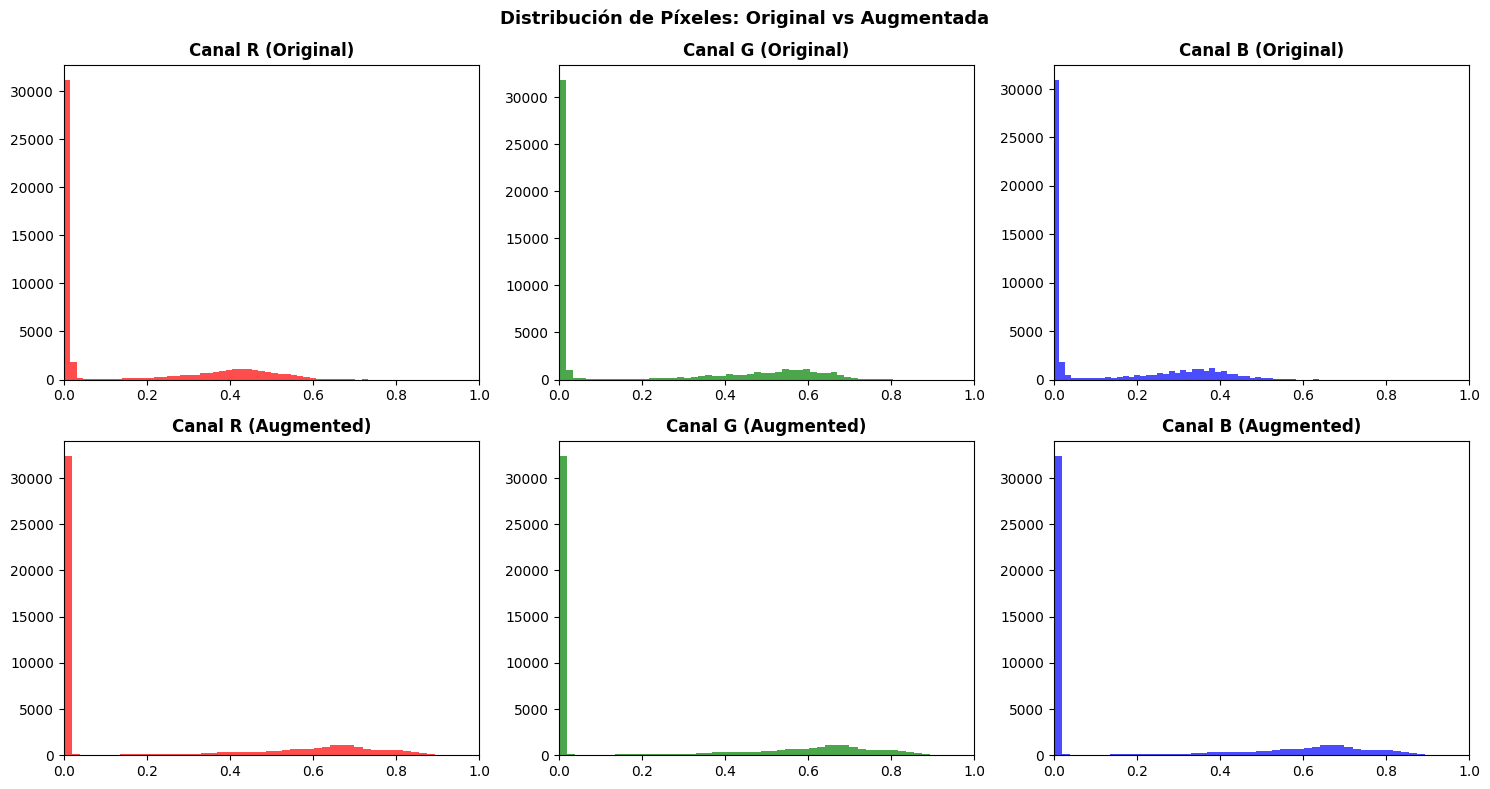

 Gráfico guardado: aug_histogramas_rgb.png


In [ ]:
# ----------------------------------------------------------------
# EFECTO DEL AUGMENTATION EN EL ESPACIO DE COLOR
# Comparar histogramas RGB de original vs augmented
# ---------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
to_tensor = T.ToTensor()

# Imagen original
img_arr_orig = np.array(img_orig) / 255.0

# Imagen augmentada
aug_no_norm = T.Compose([t for t in transform_aug.transforms
                          if not isinstance(t, (T.ToTensor, T.Normalize))])
img_aug_demo = aug_no_norm(img_orig)
img_arr_aug  = np.array(img_aug_demo) / 255.0

titles_orig = ['Canal R (Original)', 'Canal G (Original)', 'Canal B (Original)']
titles_aug  = ['Canal R (Augmented)', 'Canal G (Augmented)', 'Canal B (Augmented)']
colors = ['red', 'green', 'blue']

for i in range(3):
    axes[0, i].hist(img_arr_orig[:,:,i].ravel(), bins=50, color=colors[i], alpha=0.7)
    axes[0, i].set_title(titles_orig[i], fontweight='bold')
    axes[0, i].set_xlim(0, 1)

    axes[1, i].hist(img_arr_aug[:,:,i].ravel(), bins=50, color=colors[i], alpha=0.7)
    axes[1, i].set_title(titles_aug[i], fontweight='bold')
    axes[1, i].set_xlim(0, 1)

plt.suptitle('Distribución de Píxeles: Original vs Augmentada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aug_histogramas_rgb.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Gráfico guardado: aug_histogramas_rgb.png")


---
## 6. Construcción de DataLoaders con PyTorch

Se crean DataLoaders para train (con augmentation), val y test (sin augmentation).


In [ ]:
# ----------------------------------------------------------------
# DATASET PERSONALIZADO (usa los splits del CSV)
# -----------------------------------------------------------------
from torch.utils.data import Dataset

class PlantVillageDataset(Dataset):
    """Dataset personalizado para PlantVillage usando splits predefinidos."""

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        # Mapear clases a índices
        self.classes   = sorted(df['label'].unique())
        self.class2idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = self.class2idx[row['label']]
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_class_weights(self):
        """Retorna pesos por clase para manejar desbalanceo."""
        counts    = self.df['label'].value_counts()
        n_samples = len(self.df)
        weights   = {cls: n_samples / (len(counts) * cnt)
                     for cls, cnt in counts.items()}
        return torch.tensor([weights[c] for c in self.classes], dtype=torch.float32)


# Crear datasets
ds_train = PlantVillageDataset(df_train, transform=transform_aug)
ds_val   = PlantVillageDataset(df_val,   transform=transform_base)
ds_test  = PlantVillageDataset(df_test,  transform=transform_base)

print(f" Datasets creados:")
print(f"   Train      : {len(ds_train):,} muestras — CON augmentation")
print(f"   Validation : {len(ds_val):,} muestras — SIN augmentation")
print(f"   Test       : {len(ds_test):,} muestras — SIN augmentation")
print(f"   Num clases : {len(ds_train.classes)}")


 Datasets creados:
   Train      : 15,094 muestras — CON augmentation
   Validation : 3,234 muestras — SIN augmentation
   Test       : 3,235 muestras — SIN augmentation
   Num clases : 15


In [ ]:
# ──────────────────────────────────────────────────────────────────
# DATALOADERS
# ──────────────────────────────────────────────────────────────────
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2

loader_train = DataLoader(
    ds_train, batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda'),
    drop_last=True
)

loader_val = DataLoader(
    ds_val, batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda')
)

loader_test = DataLoader(
    ds_test, batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda')
)

print(f" DataLoaders creados:")
print(f"   Dispositivo      : {DEVICE}")
print(f"   Batches en train : {len(loader_train)}")
print(f"   Batches en val   : {len(loader_val)}")
print(f"   Batches en test  : {len(loader_test)}")

# Verificar un batch
imgs_batch, labels_batch = next(iter(loader_train))
print(f"\n   Forma de un batch de train:")
print(f"   Imágenes : {imgs_batch.shape}  → (B, C, H, W)")
print(f"   Labels   : {labels_batch.shape}")
print(f"   dtype    : {imgs_batch.dtype}")
print(f"   min/max  : [{imgs_batch.min():.3f}, {imgs_batch.max():.3f}]")


 DataLoaders creados:
   Dispositivo      : cpu
   Batches en train : 471
   Batches en val   : 102
   Batches en test  : 102

   Forma de un batch de train:
   Imágenes : torch.Size([32, 3, 224, 224])  → (B, C, H, W)
   Labels   : torch.Size([32])
   dtype    : torch.float32
   min/max  : [-2.118, 2.640]


---
## 7. Verificación de la normalización

Verificamos que la normalización aplicada produce tensores con media ≈ 0 y std ≈ 1, lo cual es el objetivo al usar estadísticas ImageNet.


In [ ]:
# --------------------------------------------------------------------
# VERIFICACIÓN ESTADÍSTICA DE NORMALIZACIÓN
# --------------------------------------------------------------------
# Tomar una muestra de 5 batches para calcular estadísticas
n_batches_check = 5
means_r, means_g, means_b = [], [], []
stds_r,  stds_g,  stds_b  = [], [], []

ds_val_check = PlantVillageDataset(df_val.sample(min(500, len(df_val)), random_state=SEED),
                                    transform=transform_base)
loader_check = DataLoader(ds_val_check, batch_size=64, shuffle=False)

for i, (batch_imgs, _) in enumerate(loader_check):
    if i >= n_batches_check:
        break
    means_r.append(batch_imgs[:, 0, :, :].mean().item())
    means_g.append(batch_imgs[:, 1, :, :].mean().item())
    means_b.append(batch_imgs[:, 2, :, :].mean().item())
    stds_r.append(batch_imgs[:, 0, :, :].std().item())
    stds_g.append(batch_imgs[:, 1, :, :].std().item())
    stds_b.append(batch_imgs[:, 2, :, :].std().item())

print(" Estadísticas post-normalización (esperado: media ≈ 0, std ≈ 1):")
print(f"\n   Canal R: media = {np.mean(means_r):+.4f}  |  std = {np.mean(stds_r):.4f}")
print(f"   Canal G: media = {np.mean(means_g):+.4f}  |  std = {np.mean(stds_g):.4f}")
print(f"   Canal B: media = {np.mean(means_b):+.4f}  |  std = {np.mean(stds_b):.4f}")

# Evaluación
all_means = [np.mean(means_r), np.mean(means_g), np.mean(means_b)]
all_stds  = [np.mean(stds_r),  np.mean(stds_g),  np.mean(stds_b)]
if all(abs(m) < 0.2 for m in all_means) and all(0.7 < s < 1.3 for s in all_stds):
    print("\nNormalización correcta — Medias próximas a 0, stds próximas a 1.")
else:
    print("\nRevisar normalización — Valores fuera del rango esperado.")


 Estadísticas post-normalización (esperado: media ≈ 0, std ≈ 1):

   Canal R: media = -0.0779  |  std = 0.8126
   Canal G: media = +0.1253  |  std = 0.7198
   Canal B: media = +0.0491  |  std = 0.8856

Normalización correcta — Medias próximas a 0, stds próximas a 1.


---
## 8. Análisis del impacto esperado del Augmentation

### ¿Qué técnicas ayudan y por qué?

| Técnica | Impacto esperado | Justificación |
|---------|-----------------|---------------|
| `RandomHorizontalFlip` |  **Positivo** — Mejora generalización | Las hojas no tienen orientación preferencial |
| `RandomVerticalFlip` | **Positivo** — Diversifica orientaciones | Poco frecuente en fotos reales pero válido |
| `RandomRotation(30°)` |  **Positivo** — Invarianza rotacional | Fotos de campo tomadas desde distintos ángulos |
| `ColorJitter` |  **Positivo** — Robustez a iluminación | Iluminación varía según hora/estación |
| `RandomAffine` |  **Positivo** — Invarianza posicional | La hoja puede no estar centrada |
| `RandomGrayscale(p=0.05)` |  **Neutro-bajo** — No afecta mucho | El color es informativo; p muy baja |

### ¿Qué técnicas podrían perjudicar?

| Técnica | Por qué podría ser contraproducente |
|---------|-------------------------------------|
| `ColorJitter` con `hue > 0.15` | Cambiaría los colores de los síntomas (manchas) haciéndolos irreconocibles |
| `RandomRotation > 90°` | Podría cortar regiones con síntomas en los bordes |
| `RandomErasing` (no incluido) | Podría borrar exactamente la región con síntoma |
| `GaussianBlur agresivo` | Eliminaría texturas finas que caracterizan hongos y manchas |





---
## 9. Resumen del pipeline de preprocesamiento

```
DATASET ORIGINAL (PlantVillage)
         ↓
[1] Control de calidad
    ├── Detección de corruptos → eliminados
    └── Detección de duplicados → reportados (tasa < 1%)
         ↓
[2] División estratificada
    ├── Train  70%  (con augmentation)
    ├── Val    15%  (sin augmentation)
    └── Test   15%  (sin augmentation)
         ↓
[3] Transforms
    ├── Base (val/test): Resize → ToTensor → Normalize
    └── Aug  (train)  : Resize → RandomCrop → HFlip → VFlip
                       → Rotation → ColorJitter → Affine
                       → Grayscale → ToTensor → Normalize
         ↓
[4] DataLoaders PyTorch
    ├── loader_train (shuffle=True,  drop_last=True)
    ├── loader_val   (shuffle=False)
    └── loader_test  (shuffle=False)
```

**Listos para usar en `03_cnn_desde_cero.py` y `04_transfer_learning.py`.**
